# Базовый опыт: ОДУ и прямой метод Гиллеспи
Источник: §6.1.3 практикума, стр. 197–200. Используется βSI, без деления на N.

In [1]:
using DrWatson
@quickactivate "project"
include(srcdir("SIRPetri.jl"))
using .SIRPetri
include(srcdir("experiment_support.jl"))
using Catlab.Graphics
import Catlab.Graphics.Graphviz

## Сеть и фиксированные параметры

In [2]:
β, γ, tmax = 0.3, 0.1, 100.0
net, u0, states = build_sir_network(β, γ)
stoichiometry(net)

3×2 Matrix{Int64}:
 -1   0
  1  -1
  0   1

## Детерминированная и стохастическая траектории

In [3]:
df_det = simulate_deterministic(net, u0, (0.0, tmax); saveat=0.5, rates=[β, γ])
Random.seed!(123)
df_stoch = simulate_stochastic(net, u0, (0.0, tmax); rates=[β, γ])
save_table("sir_det.csv", df_det)
save_table("sir_stoch.csv", df_stoch)
summary = DataFrame([merge((method="ODE",), epidemic_summary(df_det)),
    merge((method="SSA",), epidemic_summary(df_stoch))])
save_table("sir_summary.csv", summary)
summary

Row,method,peak_I,peak_time,final_R,conservation_error
,String,Float64,Float64,Float64,Float64
1,ODE,952.691,0.5,999.955,2.16005e-12
2,SSA,999.0,0.0370421,1000.0,0.0


## Динамика трёх состояний

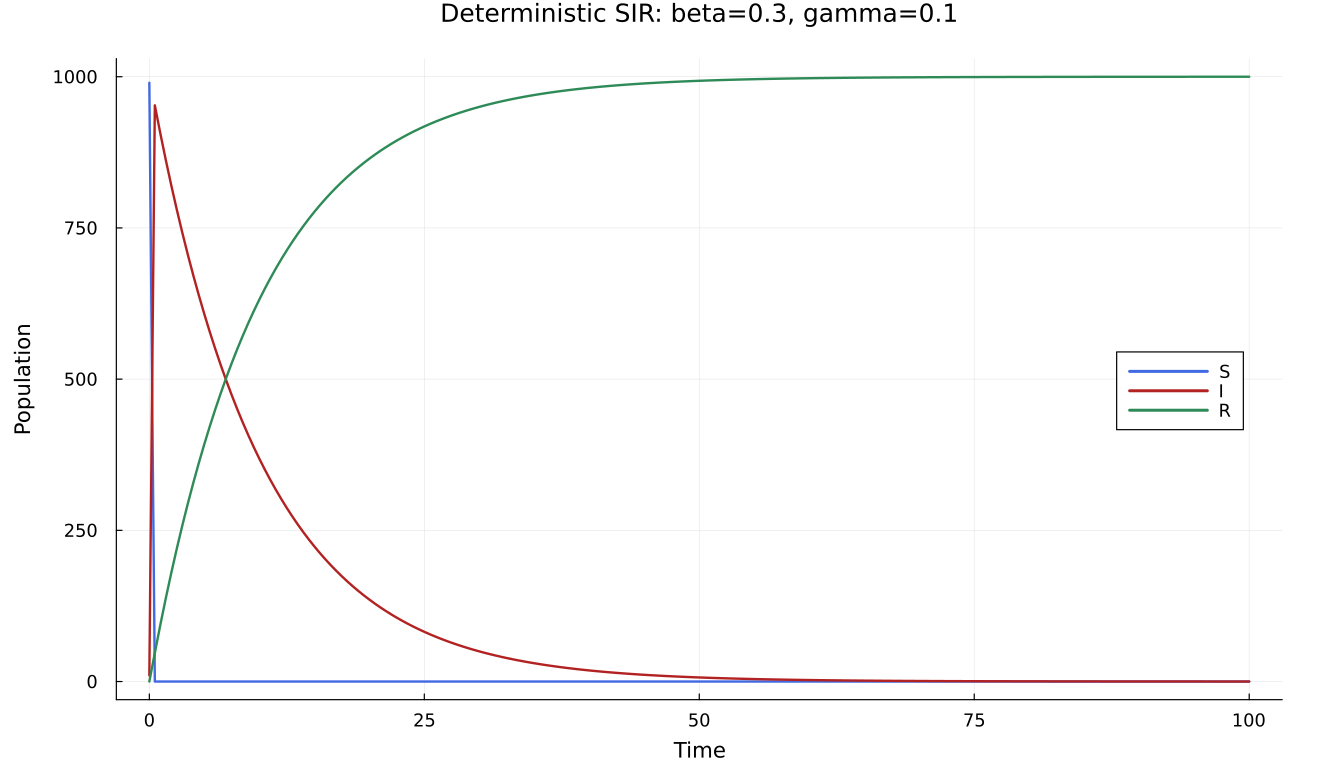

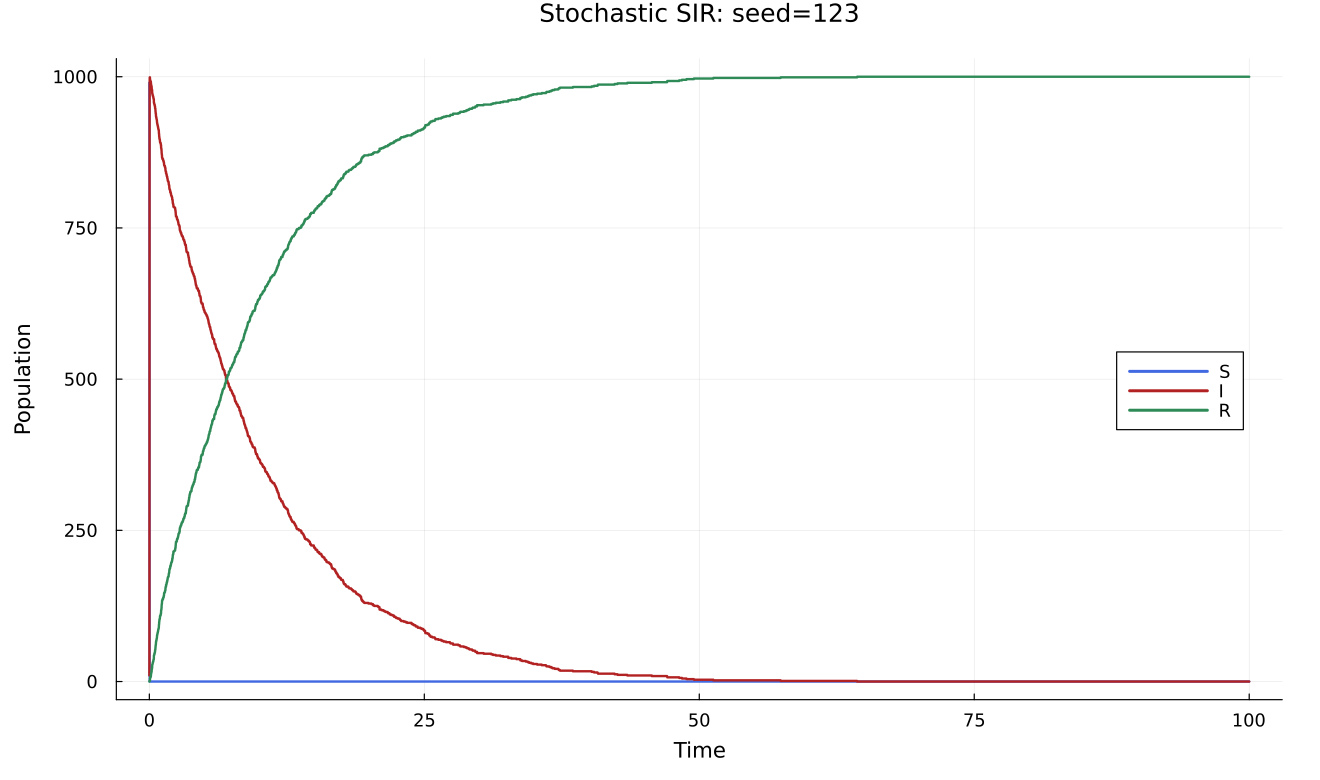

In [4]:
p_det = plot_sir(df_det; title="Deterministic SIR: beta=0.3, gamma=0.1")
savefig(p_det, imagepath("02-plot.png"))
display(p_det)
p_stoch = plot_sir(df_stoch; stochastic=true, title="Stochastic SIR: seed=123")
savefig(p_stoch, imagepath("03-plot.png"))
display(p_stoch)

## Структура сети Петри

In [5]:
open(imagepath("01-plot.png"), "w") do io
    Graphviz.run_graphviz(io, to_graphviz_sir(net); format="png")
end

## Ранний пик и ошибка дискретизации наблюдений
Шаг .5 оставлен как в методичке. Уточнение пика является отдельной проверкой.

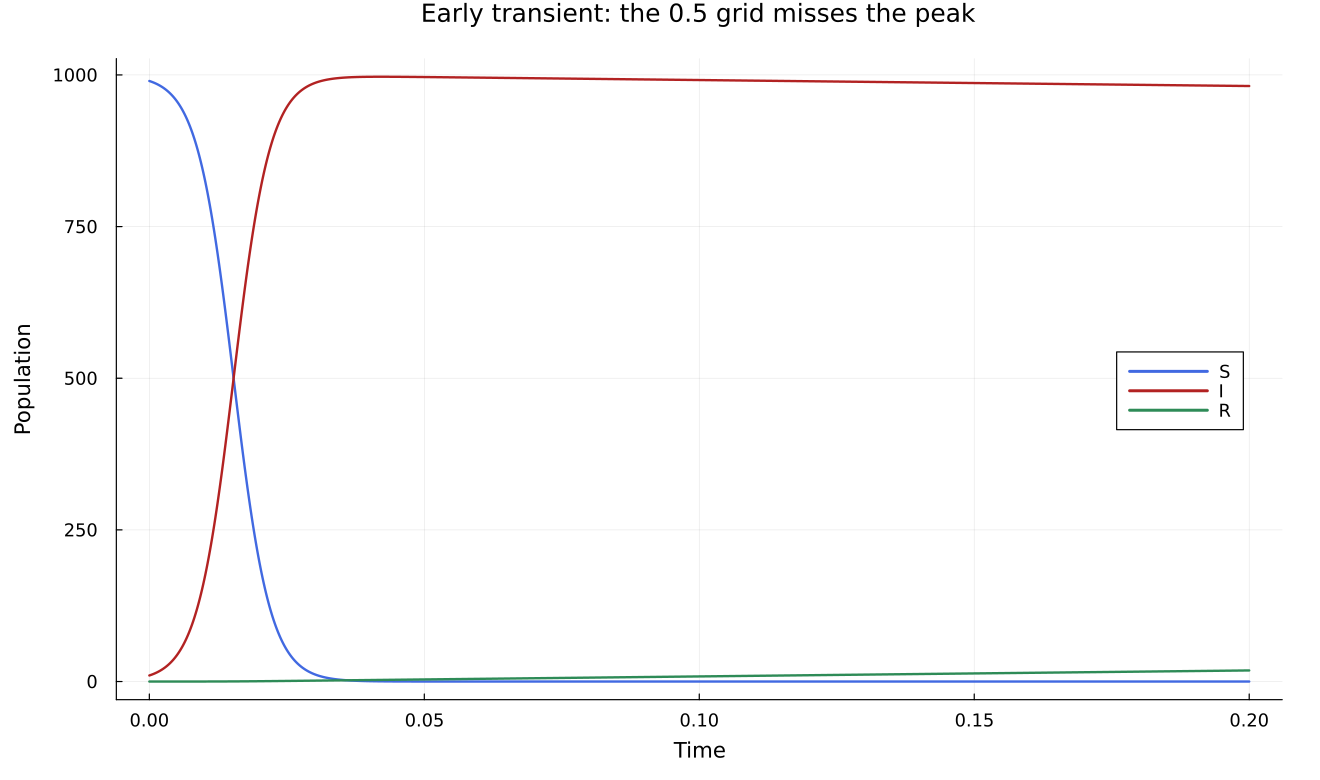

Row,time,peak,analytic
,Float64,Float64,Float64
1,0.0420463,997.001,997.001


In [6]:
fine = simulate_deterministic(net, u0, (0.0, 0.2); saveat=0.0002, rates=[β, γ])
peak = refined_peak(net, u0, (0.0, tmax); rates=[β, γ])
save_table("sir_early.csv", fine)
save_table("sir_peak_refined.csv", DataFrame([peak]))
p_early = plot_sir(fine; title="Early transient: the 0.5 grid misses the peak")
savefig(p_early, imagepath("04-plot.png"))
display(p_early)
DataFrame([peak])